<a href="https://colab.research.google.com/github/AquilaLeiteMendes/Anhanguera/blob/main/Anhanguera%20/LINGUAGEM%20DE%20PROGRAMA%C3%87%C3%83O/SISTEMA_DE_GERENCIAMENTO_DE_LIVROS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*** SISTEMA DE GERENCIAMENTO DE LIVROS ***

✓ Livro 'Dom Casmurro' cadastrado com sucesso!
✓ Livro '1984' cadastrado com sucesso!
✓ Livro 'O Senhor dos Anéis' cadastrado com sucesso!
✓ Livro 'Orgulho e Preconceito' cadastrado com sucesso!
✓ Livro 'Duna' cadastrado com sucesso!
✓ Livro 'Harry Potter e a Pedra Filosofal' cadastrado com sucesso!
✓ Livro 'A Revolução dos Bichos' cadastrado com sucesso!
✓ Livro 'Memórias Póstumas de Brás Cubas' cadastrado com sucesso!

LISTA DE LIVROS CADASTRADOS
1. Título: Dom Casmurro | Autor: Machado de Assis | Gênero: Romance | Qtd: 5
2. Título: 1984 | Autor: George Orwell | Gênero: Ficção Científica | Qtd: 3
3. Título: O Senhor dos Anéis | Autor: J.R.R. Tolkien | Gênero: Fantasia | Qtd: 4
4. Título: Orgulho e Preconceito | Autor: Jane Austen | Gênero: Romance | Qtd: 2
5. Título: Duna | Autor: Frank Herbert | Gênero: Ficção Científica | Qtd: 6
6. Título: Harry Potter e a Pedra Filosofal | Autor: J.K. Rowling | Gênero: Fantasia | Qtd: 8
7. Título: A Revo

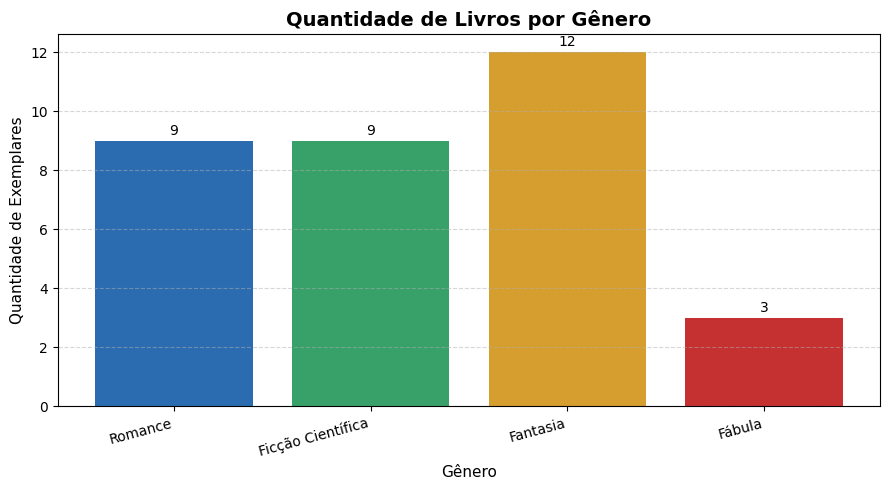


✓ Gráfico gerado com sucesso!

*** FIM DOS TESTES ***


In [2]:
# ============================================================
# Sistema de Gerenciamento de Livros em uma Biblioteca
# Disciplina: Linguagem de Programação
# Unidade: 2 – Explorando Recursos do Python
# Aula: 4 – Bibliotecas e Módulos Em Python
# Aluno: AQUILA LEITE MENDES | Matrícula: 2026452714
# ============================================================

import matplotlib.pyplot as plt
from collections import Counter
import json


class Livro:
    """
    Classe que representa um livro na biblioteca.
    Atributos:
        titulo (str): título do livro
        autor (str): nome do autor
        genero (str): gênero literário
        quantidade (int): quantidade disponível em estoque
    """
    def __init__(self, titulo, autor, genero, quantidade):
        self.titulo = titulo
        self.autor = autor
        self.genero = genero
        self.quantidade = quantidade

    def __str__(self):
        return (f"Título: {self.titulo} | Autor: {self.autor} | "
                f"Gênero: {self.genero} | Qtd: {self.quantidade}")

    def to_dict(self):
        """Converte o objeto Livro em um dicionário para exportação JSON."""
        return {
            "titulo": self.titulo,
            "autor": self.autor,
            "genero": self.genero,
            "quantidade": self.quantidade
        }

    @classmethod
    def from_dict(cls, dados):
        """Cria uma instância de Livro a partir de um dicionário."""
        return cls(dados["titulo"], dados["autor"], dados["genero"], dados["quantidade"])


# Lista que armazenará os objetos Livro
biblioteca = []


def cadastrar_livro(titulo, autor, genero, quantidade):
    """
    Cadastra um novo livro na lista da biblioteca.
    Cria uma instância da classe Livro e a adiciona à lista.
    """
    novo_livro = Livro(titulo, autor, genero, quantidade)
    biblioteca.append(novo_livro)
    print(f"✓ Livro '{titulo}' cadastrado com sucesso!")


def listar_livros():
    """
    Lista todos os livros cadastrados na biblioteca.
    Se a lista estiver vazia, informa que não há livros.
    """
    print("\n" + "=" * 60)
    print("LISTA DE LIVROS CADASTRADOS")
    print("=" * 60)
    if not biblioteca:
        print("Nenhum livro cadastrado ainda.")
    else:
        for i, livro in enumerate(biblioteca, start=1):
            print(f"{i}. {livro}")
    print("=" * 60)


def buscar_livro_por_titulo(titulo_busca):
    """
    Busca um livro pelo título (busca parcial, case-insensitive).
    Retorna a lista de livros encontrados.
    """
    encontrados = []
    titulo_busca = titulo_busca.lower().strip()
    for livro in biblioteca:
        if titulo_busca in livro.titulo.lower():
            encontrados.append(livro)

    print("\n" + "=" * 60)
    print(f"RESULTADO DA BUSCA POR: '{titulo_busca}'")
    print("=" * 60)
    if not encontrados:
        print("Nenhum livro encontrado com esse título.")
    else:
        for livro in encontrados:
            print(f"→ {livro}")
    print("=" * 60)
    return encontrados


def gerar_grafico_por_genero():
    """
    Utiliza a biblioteca Matplotlib para gerar um gráfico de barras
    mostrando a quantidade total de exemplares por gênero.
    """
    if not biblioteca:
        print("Não há livros cadastrados para gerar o gráfico.")
        return

    # Conta a quantidade de exemplares por gênero
    contagem = Counter()
    for livro in biblioteca:
        contagem[livro.genero] += livro.quantidade

    generos = list(contagem.keys())
    quantidades = list(contagem.values())

    plt.figure(figsize=(9, 5))
    barras = plt.bar(
        generos,
        quantidades,
        color=['#2b6cb0', '#38a169', '#d69e2e', '#c53030', '#805ad5', '#dd6b20']
    )
    plt.title('Quantidade de Livros por Gênero', fontsize=14, fontweight='bold')
    plt.xlabel('Gênero', fontsize=11)
    plt.ylabel('Quantidade de Exemplares', fontsize=11)
    plt.xticks(rotation=15, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Exibe o valor em cima de cada barra
    for barra in barras:
        altura = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width() / 2.,
            altura + 0.1,
            f'{int(altura)}',
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.tight_layout()
    plt.savefig('grafico_livros_por_genero.png', dpi=150)
    plt.show()  # Exibe o gráfico no Colab
    print("\n✓ Gráfico gerado com sucesso!")


def salvar_biblioteca_json(nome_arquivo='biblioteca.json'):
    """
    Salva todos os livros cadastrados na lista da biblioteca em um arquivo JSON.
    """
    try:
        lista_dict = [livro.to_dict() for livro in biblioteca]
        with open(nome_arquivo, 'w', encoding='utf-8') as f:
            json.dump(lista_dict, f, ensure_ascii=False, indent=4)
        print(f"\n✓ Biblioteca salva em '{nome_arquivo}' com sucesso!")
    except Exception as e:
        print(f"Erro ao salvar a biblioteca: {e}")


def carregar_biblioteca_json(nome_arquivo='biblioteca.json'):
    """
    Carrega livros de um arquivo JSON e preenche a lista da biblioteca.
    """
    global biblioteca
    try:
        with open(nome_arquivo, 'r', encoding='utf-8') as f:
            lista_dict = json.load(f)
        biblioteca = [Livro.from_dict(dados) for dados in lista_dict]
        print(f"\n✓ Biblioteca carregada de '{nome_arquivo}' com sucesso!")
    except FileNotFoundError:
        print(f"\n⚠ Arquivo '{nome_arquivo}' não encontrado. Nenhuma alteração feita.")
    except Exception as e:
        print(f"Erro ao carregar a biblioteca: {e}")


# ============================================================
# TESTE DO SISTEMA
# ============================================================
print("*** SISTEMA DE GERENCIAMENTO DE LIVROS ***\n")

# Cadastro de livros de exemplo
cadastrar_livro("Dom Casmurro", "Machado de Assis", "Romance", 5)
cadastrar_livro("1984", "George Orwell", "Ficção Científica", 3)
cadastrar_livro("O Senhor dos Anéis", "J.R.R. Tolkien", "Fantasia", 4)
cadastrar_livro("Orgulho e Preconceito", "Jane Austen", "Romance", 2)
cadastrar_livro("Duna", "Frank Herbert", "Ficção Científica", 6)
cadastrar_livro("Harry Potter e a Pedra Filosofal", "J.K. Rowling", "Fantasia", 8)
cadastrar_livro("A Revolução dos Bichos", "George Orwell", "Fábula", 3)
cadastrar_livro("Memórias Póstumas de Brás Cubas", "Machado de Assis", "Romance", 2)

# Listar todos os livros cadastrados inicialmente
listar_livros()

# Salvar biblioteca em arquivo JSON
salvar_biblioteca_json()

# Limpar a biblioteca local para testar a restauração dos dados
print("\n[Limpando a biblioteca em memória...]")
biblioteca = []
listar_livros()

# Carregar biblioteca novamente a partir do arquivo JSON
carregar_biblioteca_json()
listar_livros()

# Buscar livros por título
buscar_livro_por_titulo("senhor")
buscar_livro_por_titulo("1984")

# Gerar gráfico de quantidade por gênero
gerar_grafico_por_genero()

print("\n*** FIM DOS TESTES ***")